In [24]:
import nbformat
from nbconvert import PythonExporter
import os
import pandas as pd
import plotly.express as px  


notebook_paths = [
    'src/option_price/exact_option_pricing.ipynb',
    'src/option_price/qmc_option_pricing.ipynb',
    'src/seq/class_modify_sobol.ipynb',
    'test/test.ipynb'
]

# Текущая рабочая директория
current_dir = os.getcwd()
parent_dir = os.path.join(current_dir, '..')
for notebook_path in notebook_paths:
    
    full_path = os.path.join(current_dir, notebook_path)  # формируем полный путь

    if not os.path.isfile(full_path):
        print(f"❌ Файл не найден: {full_path}")
        continue

    try:
        print(f"🚀 Выполняется: {full_path}")

        # Читаем ноутбук
        with open(full_path, 'r', encoding='utf-8') as f:
            notebook_content = nbformat.read(f, as_version=4)

        # Конвертируем ноутбук в Python-код
        python_exporter = PythonExporter()
        python_code, _ = python_exporter.from_notebook_node(notebook_content)

        # Выполняем к
        exec(python_code)

        print(f"✅ Успешно выполнен: {full_path}")

    except Exception as e:
        print(f"⚠️ Ошибка в {full_path}: {e}")

🚀 Выполняется: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\src/option_price/exact_option_pricing.ipynb
✅ Успешно выполнен: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\src/option_price/exact_option_pricing.ipynb
🚀 Выполняется: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\src/option_price/qmc_option_pricing.ipynb
✅ Успешно выполнен: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\src/option_price/qmc_option_pricing.ipynb
🚀 Выполняется: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\src/seq/class_modify_sobol.ipynb
✅ Успешно выполнен: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\src/seq/class_modify_sobol.ipynb
🚀 Выполняется: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\test/test.ipynb
❌ Файл не найден: C:\Users\Vlada\Desktop\Sirius\NIR\src\option_price\exact_option_pricing.ipynb
❌ Файл не найден: C:\Users\Vlada\Desktop\Sirius\NIR\src\option_price\qmc_option_pricing.ipynb
❌ Файл не найден: C:\Us

### Функции

In [25]:
def graph_one_2D(arr, d_1, d_2, title: str, color: str):
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(x=arr[:,d_1-1], y=arr[:,d_2-1], mode='markers', line=dict(color=color)))

    fig.update_layout(
        title=title,
        xaxis_title=f'dim={d_1}',
        yaxis_title=f'dim={d_2}',
        width=500,
        height=500,
        template='plotly_white'
    )
    
    fig.show()


In [26]:
def _1D_gaph(data,title_):
    fig = go.Figure()

    fig.add_trace(go.Scatter(x=data, y=[0] * len(data), mode='lines+markers', 
                             line=dict(color='lightblue'), 
                             marker=dict(color='black', size=7),
                             name='Data'))
    fig.update_layout(
        title= title_,
        xaxis=dict(title='X-axis'),
        yaxis=dict(visible=False),  # cкрытие оси Y
        showlegend=True,
        autosize=False,
        width=1000,
        height=300,
        plot_bgcolor='rgba(128, 128, 128, 0.2)',  
        paper_bgcolor='white',
        title_x=0.5
    )

    fig.show()

In [42]:
# 3D график
def graph_3d(arr, d_1, d_2, d_3):
    fig = go.Figure()

    fig.add_trace(go.Scatter3d(x=arr[:,d_1-1], y=arr[:,d_2-1], z=arr[:,d_3-1], mode='markers', 
                             marker=dict(color='lightgreen', size=5, 
                                         line=dict(color='purple', width=0.5)), 
                             name='Data'))

    fig.update_layout(
        scene=dict(
            xaxis_title=f'dim = {d_1}',
            yaxis_title=f'dim = {d_2}',
            zaxis_title=f'dim = {d_3}',
        ),
        width=800,
        height=800,
        scene_aspectmode='cube',
        plot_bgcolor='rgba(128, 128, 128, 0.2)',  
        paper_bgcolor='white'
    )

    fig.show()


In [31]:
def farei_sequence(n):
    result = ['0/1']
    
    def farei_sequence_rec(n, x, y, z, t):
        a, b = x + z, y + t
        if b <= n:
            farei_sequence_rec(n, x, y, a, b)
            result.append(f'{a}/{b}')
            farei_sequence_rec(n, a, b, z, t)
      
    farei_sequence_rec(n, 0, 1, 1, 1)
    result.append('1/1')
    return result

### Классический Фарей

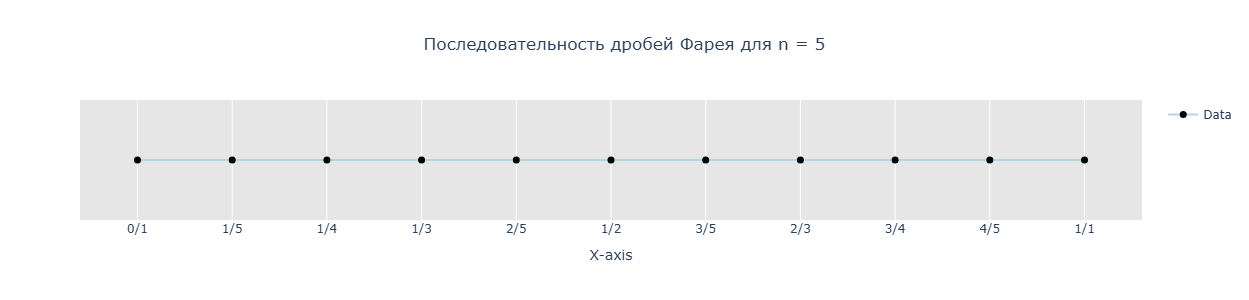

In [32]:
F_L = farei_sequence(5) 
title__= "Последовательность дробей Фарея для n = 5"
_1D_gaph(F_L, title__)

### Модифицированный Фарей

In [33]:
dim = 100
m = 10
n0 = 1
seq_= LowDiscrepancySequence(dim, n0, m)
arr = seq_.get_seq('sobol_farey')

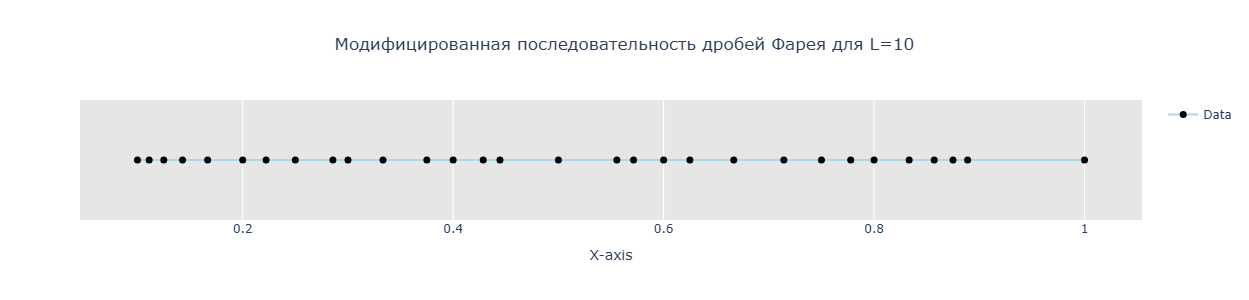

In [34]:
F_L = seq_.farey_seq(30) 
title_ = "Модифицированная последовательность дробей Фарея для L=10"
van_der_corput_gaph(F_L, title_)

### Многомерный Соболь-Фарей

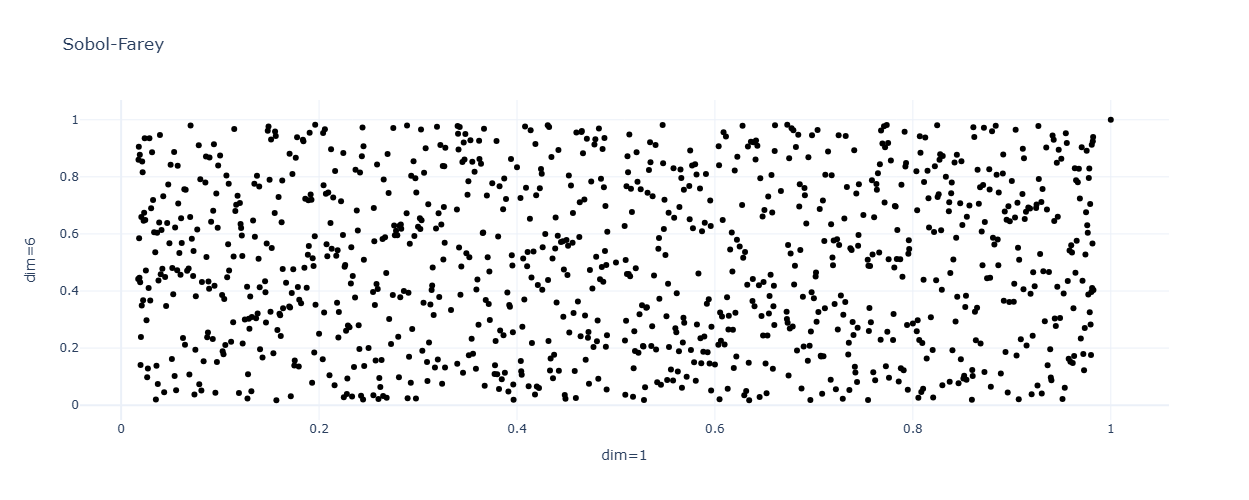

In [35]:
d_1 = 1
d_2 = 6
title ='Sobol-Farey'
color = 'black'
graph_one_2D(arr, d_1, d_2, title, color)

### Сравнение Дискрипанси

In [43]:
def dic(dim, m):
    n0 = 1
    sequence = []
    sequence.append(LowDiscrepancySequence(dim, n0, m).get_seq('sobol_farey'))
    sequence.append(LowDiscrepancySequence(dim, n0, m).get_seq('sobol_lcg'))
    sequence.append(LowDiscrepancySequence(dim, n0, m).get_seq('halton'))
    sequence.append(LowDiscrepancySequence(dim, n0, m).get_seq('kronecker'))
    # sequence.append(LowDiscrepancySequence(dim, n0, m).get_seq('sobol_kronecker'))
    sequence.append(LowDiscrepancySequence(dim, n0, m).get_seq('faure'))
    sequence.append(qmc.Sobol(d=dim, scramble=False).random_base2(m+1)[1:2**m+1])
   
    disc = []
    for i in sequence:
        disc.append(qmc.discrepancy(i))
    # disc = pd.DataFrame(disc)
    return disc

In [ ]:
dim_ =15
arr = []

for d in tqdm(range(dim_)):
    m = 13
    dim = d + 1
    arr.append(dic(dim, m))

df0 = pd.DataFrame(arr, index = range(1, dim_ + 1), columns = ['sobol_farey', 'sobol_lcg', 'halton','kronecker','faure','sobol'])

 93%|████████████████████████████████████████████████████████████████████████████▌     | 14/15 [05:09<00:33, 33.52s/it]

In [ ]:
df0

In [ ]:
df0.index = range(1, len(df0) + 1)

df_long = df0.reset_index().melt(
    id_vars='index',
    value_vars=['sobol_farey', 'sobol_lcg', 'halton','kronecker','faure','sobol'],
    var_name='Sequence',
    value_name='Discrepancy'
)

# Построим график
fig = px.line(
    df_long,
    x='index',
    y='Discrepancy',
    color='Sequence',
    markers=True,
    title='Discrepancy for Various Quasi-Random Sequences'
)

fig.update_layout(
    xaxis_title='Dimention',
    yaxis_title='Discrepancy',
    template='plotly_white',
    width=1000,
    height=500
)


fig.show()


In [ ]:
df0.plot()

---

### Ценообразование опционов

In [ ]:
dim = 15
m = 13
sequences_names = ['sobol_farey', 'sobol_lcg', 'halton','kronecker','faure','sobol']

sobol_seq = Test_seq( dim, m, sequences_names)

In [ ]:
S_0 = 95 
K = 100  
r = 0.21
sigma = 0.2  
T = 1
option_type="call"
t = 0.0
B = 150
S_max = 150

options_data = [S_0, K, r, sigma, T, option_type, t, B, S_max]



In [ ]:
sobol_seq.find_options_prices(options_data)

In [ ]:
sobol_seq.find_options_errors(options_data)

In [ ]:
df = sobol_seq.find__options_prices_time_steps(options_data)
df 

In [ ]:
title = 'European option'
dff = df['European']
sobol_seq.plot_option(dff, title)

In [ ]:
title2 = 'Up-and-Out option'
dff2 = df['Up-and-Out']
sobol_seq.plot_option(dff2, title2)

In [ ]:
title3 = 'Lookback option'
dff3 = df['Lookback']
sobol_seq.plot_option(dff3, title3)

In [ ]:
dff3

#### Ошибки стоимости опционов на промежутке времени от t до T

In [ ]:
error_european_option = dff3.apply(lambda x: x - dff3['exact'], axis=0)
error_up_and_out_option = dff2.apply(lambda x: x - dff2['exact'], axis=0)
error_lookback_option = dff.apply(lambda x: x - dff['exact'], axis=0)


In [ ]:
def plot_option(df, title, yaxis_title, width, height):
    fig = go.Figure()
    

    for col in df.columns:
        fig.add_trace(go.Scatter(x=df.index, 
                                 y=df[col], 
                                 mode='lines+markers', 
                                 name=col))

    # Настройка графика
    fig.update_layout(title=title,
                      xaxis_title='Time steps',
                      yaxis_title=yaxis_title,
                      template='plotly_white',
                      width=width,
                      height=height)
    
    return fig



In [ ]:
fig_error_european_option = plot_option(error_european_option, 'European option Errors', 'Error', width=1200, height=400)
fig_error_up_and_out_option = plot_option(error_up_and_out_option, 'Up-and-out option Errors', 'Error', width=1200, height=400)
fig_error_lookback_option = plot_option(error_lookback_option, 'Lookback option Errors', 'Error', width=1200, height=400)

fig_error_european_option.show()
fig_error_up_and_out_option.show()
fig_error_lookback_option.show()